# DCGAN on SVHN

Adapted from the [TensorFlow DCGAN tutorial](https://www.tensorflow.org/tutorials/generative/dcgan). The original trains on MNIST (28×28 grayscale); this version uses the Street View House Numbers dataset (32×32 RGB).

**Changes from the original:**
- Dataset: `svhn_cropped` via `tensorflow_datasets` instead of `tf.keras.datasets.mnist`
- Image shape: `(32, 32, 3)` — RGB instead of grayscale
- Generator: starts at `4×4×256`, upsamples `4→8→16→32` (one extra layer vs. MNIST's `7→14→28`), outputs 3 channels
- Discriminator: input `(32, 32, 3)` with an extra strided conv layer to match depth
- Display: rescales `[-1, 1]` → `[0, 1]` and renders RGB

## 1. Imports and GPU check

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt
import os
import time
import imageio
import glob
from IPython import display

print('TF version:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TF version: 2.21.0
GPUs: []


## 2. Load SVHN

In [ ]:
BUFFER_SIZE = 60000
BATCH_SIZE = 128

ds_train = tfds.load('svhn_cropped', split='train', as_supervised=True)

def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = (image - 127.5) / 127.5  # [0, 255] -> [-1, 1]
    return image

train_dataset = (
    ds_train
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

for batch in train_dataset.take(1):
    print('Batch shape:', batch.shape)
    print('Pixel range:', float(tf.reduce_min(batch)), 'to', float(tf.reduce_max(batch)))

### Sample real images

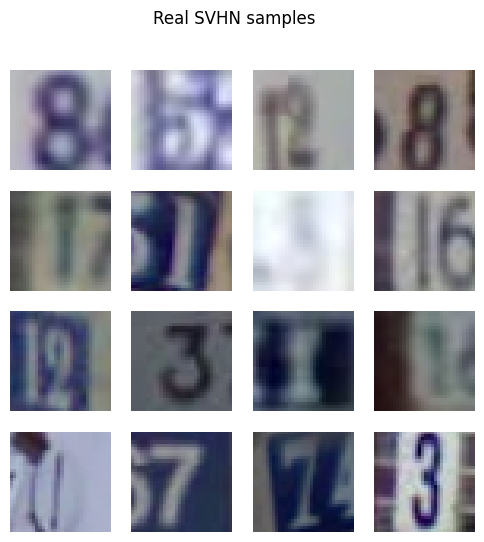

In [14]:
for batch in train_dataset.take(1):
    fig = plt.figure(figsize=(6, 6))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        img = (batch[i].numpy() + 1) / 2  # [-1, 1] -> [0, 1]
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle('Real SVHN samples')
    plt.show()

## 3. Generator

In [ ]:
NOISE_DIM = 100

def make_generator_model():
    model = tf.keras.Sequential(name='generator')

    model.add(layers.Dense(4 * 4 * 256, use_bias=False, input_shape=(NOISE_DIM,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Reshape((4, 4, 256)))

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))

    return model

generator = make_generator_model()
generator.summary()

### Untrained generator output

Generated shape: (1, 32, 32, 3)


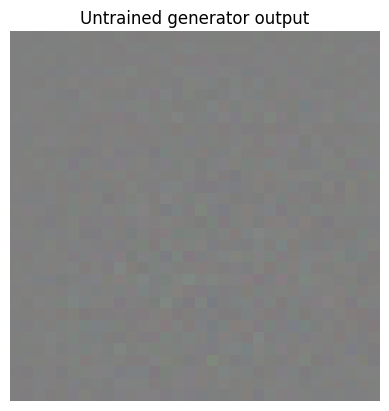

In [4]:
noise = tf.random.normal([1, NOISE_DIM])
generated_image = generator(noise, training=False)
print('Generated shape:', generated_image.shape)  # (1, 32, 32, 3)

plt.imshow((generated_image[0].numpy() + 1) / 2)
plt.axis('off')
plt.title('Untrained generator output')
plt.show()

## 4. Discriminator

In [ ]:
def make_discriminator_model():
    model = tf.keras.Sequential(name='discriminator')

    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[32, 32, 3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

discriminator = make_discriminator_model()
discriminator.summary()

decision = discriminator(generated_image)
print('Discriminator decision (logit):', float(decision[0, 0]))

## 5. Losses and optimizers

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

## 6. Checkpoints

In [19]:
checkpoint_dir = './training_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
checkpoint = tf.train.Checkpoint(
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    generator=generator,
    discriminator=discriminator,
)

## 7. Training loop

In [ ]:
EPOCHS = 50
NUM_EXAMPLES_TO_GENERATE = 16

seed = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, NOISE_DIM])

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [ ]:
os.makedirs('./generated_images', exist_ok=True)

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(6, 6))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        img = np.clip((predictions[i].numpy() + 1) / 2, 0, 1)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(f'Epoch {epoch}')
    plt.savefig(f'./generated_images/image_at_epoch_{epoch:04d}.png')
    plt.show()

def train(dataset, epochs):
    for epoch in range(1, epochs + 1):
        start = time.time()
        gen_losses, disc_losses = [], []

        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
            gen_losses.append(float(g_loss))
            disc_losses.append(float(d_loss))

        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch, seed)

        if epoch % 10 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        print(f'Epoch {epoch}/{epochs} | '
              f'gen_loss={np.mean(gen_losses):.4f} | '
              f'disc_loss={np.mean(disc_losses):.4f} | '
              f'time={time.time() - start:.1f}s')

    display.clear_output(wait=True)
    generate_and_save_images(generator, epochs, seed)

## 8. Train

In [ ]:
RUN_EPOCHS = 10
train(train_dataset, RUN_EPOCHS)

## 9. Make a GIF of training progress

In [23]:
anim_file = 'dcgan_svhn.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
    filenames = sorted(glob.glob('./generated_images/image_at_epoch_*.png'))
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

print(f'Saved {anim_file}')

Saved dcgan_svhn.gif


/var/folders/hc/lxb0qvhj0v9cq5z96yjx_nbh0000gn/T/ipykernel_32178/2993206204.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


## 10. Final samples from the trained generator

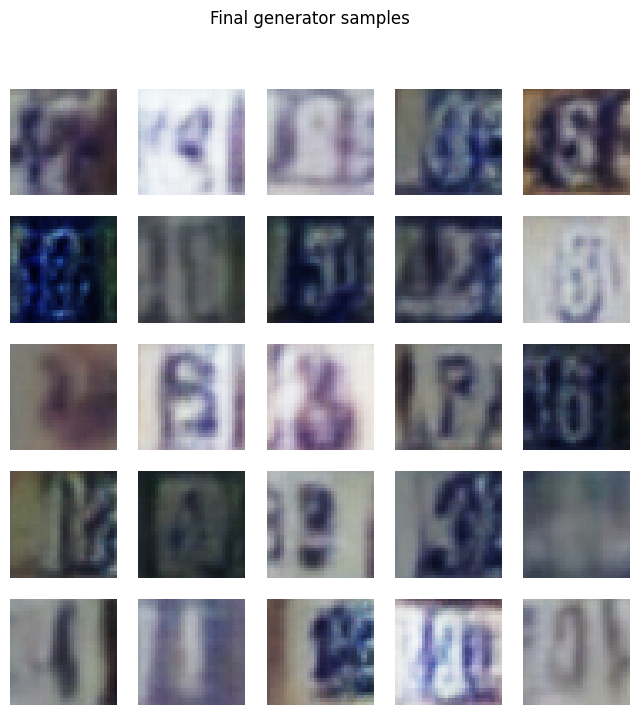

In [24]:
final_noise = tf.random.normal([25, NOISE_DIM])
final_images = generator(final_noise, training=False)

fig = plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    img = (final_images[i].numpy() + 1) / 2
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')
plt.suptitle('Final generator samples')
plt.savefig('./generated_images/final_samples.png')
plt.show()